# 05. Dane mieszane: kategorie, braki danych i pipeline

Cel: pokazać bardziej realistyczny przypadek, w którym mamy:

- cechy liczbowe,
- cechy kategoryczne,
- pojedyncze braki danych,
- podział train/test,
- interpretację drzewa po zakodowaniu kategorii.

Przykład: przewidywanie, czy klient odejdzie z usługi.

## Dlaczego ten notebook jest ważny?

Poprzednie notebooki miały dane dość „czyste”:

```text
same liczby
mało kolumn
brak większych problemów technicznych
```

W praktyce dane często są mieszane:

```text
wiek = liczba
plan = tekst
umowa = tekst
liczba_reklamacji = liczba
braki danych = NaN
```

Ten notebook pokazuje, jak połączyć drzewo decyzyjne z preprocessingiem w jednym obiekcie `Pipeline`.

To jest pierwszy notebook, który przypomina prawdziwy mini-proces ML.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

BASE = Path.cwd()
for candidate in [BASE, BASE.parent, Path("/mnt/data/drzewa_decyzyjne_dydaktyka")]:
    if (candidate / "data" / "04_klienci_churn.csv").exists():
        BASE = candidate
        break
else:
    BASE = Path.cwd()

csv_path = BASE / "data" / "04_klienci_churn.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    # Fallback dydaktyczny: fikcyjny churn klientów.
    rng = np.random.default_rng(42)
    n = 240
    miesiace_umowy = rng.integers(1, 49, n)
    liczba_reklamacji = rng.poisson(1.1, n)
    srednie_logowania_tyg = np.clip(rng.normal(5.0, 2.3, n), 0, 14).round(1)
    plan = rng.choice(["basic", "pro", "premium"], size=n, p=[0.45, 0.38, 0.17]).astype(object)
    umowa = rng.choice(["miesieczna", "roczna", "dwuletnia"], size=n, p=[0.55, 0.30, 0.15]).astype(object)
    rabat = rng.choice(["tak", "nie"], size=n, p=[0.35, 0.65]).astype(object)

    logit = (
        0.0
        + 0.9 * (umowa == "miesieczna")
        + 0.45 * (plan == "basic")
        + 0.55 * (liczba_reklamacji >= 2)
        - 0.035 * miesiace_umowy
        - 0.18 * srednie_logowania_tyg
        - 0.25 * (rabat == "tak")
    )
    prob = 1 / (1 + np.exp(-logit))
    odejdzie = np.where(rng.random(n) < prob, "tak", "nie")

    df = pd.DataFrame({
        "klient_id": range(1, n + 1),
        "miesiace_umowy": miesiace_umowy,
        "liczba_reklamacji": liczba_reklamacji,
        "srednie_logowania_tyg": srednie_logowania_tyg,
        "plan": plan,
        "umowa": umowa,
        "rabat": rabat,
        "odejdzie": odejdzie,
    })

    # Dodajemy kilka braków danych, żeby pipeline miał co robić.
    df.loc[rng.choice(n, 10, replace=False), "srednie_logowania_tyg"] = np.nan
    df.loc[rng.choice(n, 7, replace=False), "plan"] = np.nan
    df.loc[rng.choice(n, 6, replace=False), "rabat"] = np.nan

df.head()


,klient_id,miesiace_umowy,liczba_reklamacji,srednie_logowania_tyg,plan,umowa,rabat,odejdzie
0,1,5,2,NaN,pro,dwuletnia,nie,nie
1,2,38,1,3.6,premium,miesieczna,tak,nie
2,3,32,1,3.5,basic,miesieczna,nie,tak
3,4,22,0,6.2,basic,roczna,nie,tak
4,5,21,0,6.8,pro,miesieczna,nie,nie


In [3]:
df

,klient_id,miesiace_umowy,liczba_reklamacji,srednie_logowania_tyg,plan,umowa,rabat,odejdzie
0,1,5,2,NaN,pro,dwuletnia,nie,nie
1,2,38,1,3.6,premium,miesieczna,tak,nie
2,3,32,1,3.5,basic,miesieczna,nie,tak
3,4,22,0,6.2,basic,roczna,nie,tak
4,5,21,0,6.8,pro,miesieczna,nie,nie
...,...,...,...,...,...,...,...,...
235,236,35,2,8.3,basic,miesieczna,tak,nie
236,237,32,0,9.2,basic,roczna,tak,nie
237,238,21,0,4.2,basic,roczna,tak,nie
238,239,15,3,9.4,pro,miesieczna,nie,nie


In [3]:
print(df.isna().sum())
print()
print(df["odejdzie"].value_counts(normalize=True))

klient_id                 0
miesiace_umowy            0
liczba_reklamacji         0
srednie_logowania_tyg    10
plan                      7
umowa                     0
rabat                     6
odejdzie                  0
dtype: int64

nie    0.720833
tak    0.279167
Name: odejdzie, dtype: float64


## Co oznaczają dane?

Próbujemy przewidzieć, czy klient odejdzie z usługi (`odejdzie`).

Mamy cechy liczbowe:

- `miesiace_umowy` — jak długo klient jest z firmą,
- `liczba_reklamacji` — ile reklamacji zgłosił,
- `srednie_logowania_tyg` — ile razy średnio loguje się tygodniowo.

Mamy też cechy kategoryczne:

- `plan` — typ planu,
- `umowa` — typ umowy,
- `rabat` — czy klient ma rabat.

Nowość w tym notebooku:
model nie dostaje już tylko liczb. Musimy przygotować dane mieszane.

## 1. Przygotowanie danych

Scikit-learnowe drzewo nie przyjmuje bezpośrednio tekstowych kategorii w stylu `basic`, `pro`, `roczna`. Dlatego tworzymy pipeline:

1. dla liczb: uzupełnij braki medianą,
2. dla kategorii: uzupełnij najczęstszą wartością i wykonaj one-hot encoding,
3. naucz drzewo decyzyjne.

### Co dokładnie robi pipeline?

Pipeline składa się z dwóch etapów:

```text
preprocessing → model
```

W preprocessingu osobno traktujemy:

```text
cechy liczbowe:
    uzupełnij braki medianą

cechy kategoryczne:
    uzupełnij braki najczęstszą wartością
    zamień kategorie na kolumny 0/1 przez OneHotEncoder
```

Dopiero po tych krokach dane trafiają do drzewa.

Dzięki temu nie musimy ręcznie pilnować, żeby identyczne przekształcenia wykonać na train i test.

In [4]:
X = df.drop(columns=["odejdzie", "klient_id"])
y = df["odejdzie"]

num_cols = ["miesiace_umowy", "liczba_reklamacji", "srednie_logowania_tyg"]
cat_cols = ["plan", "umowa", "rabat"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

pipe = Pipeline([
    ("prep", preprocess),
    ("tree", DecisionTreeClassifier(max_depth=3, min_samples_leaf=4, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)
print("Gotowe — pipeline wytrenowany.")

Gotowe — pipeline wytrenowany.


In [5]:
print("Cechy liczbowe:")
print(num_cols)

print("\nCechy kategoryczne:")
print(cat_cols)

df[num_cols + cat_cols].head()

Cechy liczbowe:
['miesiace_umowy', 'liczba_reklamacji', 'srednie_logowania_tyg']

Cechy kategoryczne:
['plan', 'umowa', 'rabat']


,miesiace_umowy,liczba_reklamacji,srednie_logowania_tyg,plan,umowa,rabat
0,5,2,NaN,pro,dwuletnia,nie
1,38,1,3.6,premium,miesieczna,tak
2,32,1,3.5,basic,miesieczna,nie
3,22,0,6.2,basic,roczna,nie
4,21,0,6.8,pro,miesieczna,nie


### Przykład jak działą one-hot encoding

In [6]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()

one_client = X_train.iloc[[0]]

print("Przed preprocessingiem:")
display(one_client)

one_client_transformed = pipe.named_steps["prep"].transform(one_client)

one_client_transformed_df = pd.DataFrame(
    one_client_transformed,
    columns=feature_names,
    index=one_client.index
)

print("Po preprocessingiu:")
display(one_client_transformed_df)

Przed preprocessingiem:


,miesiace_umowy,liczba_reklamacji,srednie_logowania_tyg,plan,umowa,rabat
125,28,0,6.8,basic,miesieczna,nie


Po preprocessingiu:


,num__miesiace_umowy,num__liczba_reklamacji,num__srednie_logowania_tyg,cat__plan_basic,cat__plan_premium,cat__plan_pro,cat__umowa_dwuletnia,cat__umowa_miesieczna,cat__umowa_roczna,cat__rabat_nie,cat__rabat_tak
125,28.0,0.0,6.8,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


Widzimy, że jeden klient przed preprocessingiem miał kolumny tekstowe,
np. `plan`, `umowa`, `rabat`.

Po preprocessingiu tekst znika,
a zamiast niego pojawiają się kolumny zero-jedynkowe.

Dopiero taką tabelę widzi drzewo decyzyjne.

#### Jupyter pokazuje tu schemat pipeline'u: najpierw wykonywany jest preprocessing (`prep`), a dopiero potem model (`tree`). To nie są wyniki modelu, tylko struktura obiektu.

To nie są wyniki modelu, tylko schemat obiektu: najpierw `prep`, potem `tree`.

In [7]:
pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['miesiace_umowy',
                                                   'liczba_reklamacji',
                                                   'srednie_logowania_tyg']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['plan', 'umowa',
                                                   'rabat'])])),
                ('tree',
                 DecisionTreeClassifier(max_depth=3, min_samples_leaf=4,
                                        random_state=42))])

## Co pipeline zrobił z danymi?

Pipeline ukrywa wiele kroków w jednej komendzie.

Dlatego teraz zobaczymy, jak wygląda `X_train`
po uzupełnieniu braków i zakodowaniu kategorii.

In [8]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()

X_train_transformed = pipe.named_steps["prep"].transform(X_train)

X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index
)

X_train_transformed_df.head()

,num__miesiace_umowy,num__liczba_reklamacji,num__srednie_logowania_tyg,cat__plan_basic,cat__plan_premium,cat__plan_pro,cat__umowa_dwuletnia,cat__umowa_miesieczna,cat__umowa_roczna,cat__rabat_nie,cat__rabat_tak
125,28.0,0.0,6.8,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
79,33.0,3.0,6.4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
26,20.0,0.0,2.6,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
204,22.0,0.0,4.7,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
144,48.0,0.0,9.1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


Kolumny zaczynające się od `num__` to cechy liczbowe po preprocessingu.

Kolumny zaczynające się od `cat__` to cechy kategoryczne po one-hot encodingu.

Na przykład:

`cat__umowa_miesieczna = 1`

oznacza, że klient ma umowę miesięczną.

`cat__umowa_miesieczna = 0`

oznacza, że klient nie ma umowy miesięcznej.

## 2. Ocena modelu

W tym przykładzie nie chodzi o bicie rekordów jakości, tylko o pokazanie pełnego procesu: dane → preprocessing → drzewo → interpretacja.

### Po co baseline?

Jeżeli większość klientów nie odchodzi, model może mieć niezłą accuracy nawet wtedy, gdy zawsze przewiduje:

```text
odejdzie = nie
```

Dlatego porównujemy drzewo z prostym modelem bazowym.

Baseline odpowiada na pytanie:

> Czy nasze drzewo jest lepsze niż bardzo prosta, naiwna strategia?


Krótki wniosek pod wynikami:

```markdown
W tym przykładzie baseline osiąga wysoką accuracy,
bo większość klientów nie odchodzi.

To pokazuje, że sama accuracy może być myląca:
model może wyglądać dobrze tylko dlatego,
że zawsze przewiduje dominującą klasę.

## Intuicja baseline'u

Baseline to bardzo prosty „naiwny model”.

Nie analizuje żadnych cech klienta.
Nie używa drzewa ani ML.

Robi tylko jedną rzecz:

```text
zawsze przewiduje najczęstszą klasę
```

Jeśli większość klientów nie odchodzi,
baseline dla każdego klienta przewidzi:

```text
odejdzie = nie
```

Nawet taki bardzo prosty model może mieć niezłą accuracy,
jeśli klasy są niezbalansowane.

Dlatego baseline jest punktem odniesienia:

```text
czy nasze prawdziwe drzewo robi coś lepszego
niż bardzo naiwna strategia?
```

Baseline, czyli zawsze przewiduj najczęstszą klasę:
  klasa: nie
  accuracy: 0.722

Pojedyncze drzewo:
  accuracy: 0.653

              precision    recall  f1-score   support

         nie       0.74      0.81      0.77        52
         tak       0.33      0.25      0.29        20

    accuracy                           0.65        72
   macro avg       0.54      0.53      0.53        72
weighted avg       0.62      0.65      0.64        72



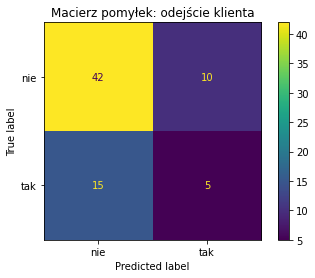

In [9]:
y_pred = pipe.predict(X_test)

baseline_class = y_train.mode().iloc[0]
baseline_pred = pd.Series([baseline_class] * len(y_test), index=y_test.index)

print("Baseline, czyli zawsze przewiduj najczęstszą klasę:")
print("  klasa:", baseline_class)
print("  accuracy:", round(accuracy_score(y_test, baseline_pred), 3))
print()
print("Pojedyncze drzewo:")
print("  accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Macierz pomyłek: odejście klienta")
plt.show()


In [20]:
#y_pred = pipe.predict(X_test)

baseline_class = y_train.mode().iloc[0]
#baseline_pred = pd.Series([baseline_class] * len(y_test), index=y_test.index)
baseline_class

'nie'

In [21]:
baseline_pred

71     nie
113    nie
187    nie
239    nie
182    nie
      ... 
207    nie
101    nie
142    nie
143    nie
170    nie
Length: 72, dtype: object

In [22]:
y_test

71     nie
113    tak
187    nie
239    tak
182    nie
      ... 
207    nie
101    nie
142    nie
143    nie
170    tak
Name: odejdzie, Length: 72, dtype: object

In [27]:
baseline_pred[baseline_pred=='tak']

Series([], dtype: object)

In [23]:
y_pred

array(['nie', 'nie', 'nie', 'nie', 'nie', 'nie', 'tak', 'nie', 'tak',
       'tak', 'tak', 'nie', 'nie', 'nie', 'nie', 'nie', 'tak', 'tak',
       'nie', 'nie', 'nie', 'nie', 'nie', 'nie', 'nie', 'nie', 'tak',
       'nie', 'nie', 'nie', 'nie', 'nie', 'nie', 'tak', 'nie', 'tak',
       'nie', 'nie', 'nie', 'nie', 'nie', 'nie', 'nie', 'nie', 'nie',
       'nie', 'tak', 'nie', 'nie', 'nie', 'nie', 'nie', 'nie', 'nie',
       'nie', 'nie', 'nie', 'nie', 'tak', 'tak', 'nie', 'nie', 'nie',
       'tak', 'nie', 'nie', 'tak', 'nie', 'tak', 'nie', 'nie', 'nie'],
      dtype=object)

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

positive_label = "tak"

print("Precision dla klasy tak:",
      round(precision_score(y_test, y_pred, pos_label=positive_label), 3))

print("Recall dla klasy tak:",
      round(recall_score(y_test, y_pred, pos_label=positive_label), 3))

print("F1 dla klasy tak:",
      round(f1_score(y_test, y_pred, pos_label=positive_label), 3))

Precision dla klasy tak: 0.333
Recall dla klasy tak: 0.25
F1 dla klasy tak: 0.286


ROC AUC: 0.518


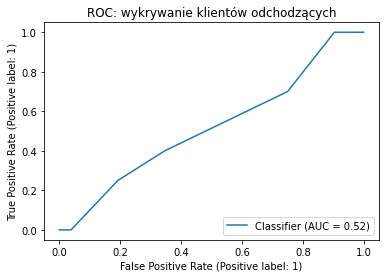

In [11]:
from sklearn.metrics import RocCurveDisplay

y_score = pipe.predict_proba(X_test)[:, list(pipe.classes_).index("tak")]

print("ROC AUC:",
      round(roc_auc_score((y_test == "tak").astype(int), y_score), 3))

RocCurveDisplay.from_predictions(
    (y_test == "tak").astype(int),
    y_score
)
plt.title("ROC: wykrywanie klientów odchodzących")
plt.show()

ROC AUC ocenia, czy model potrafi nadawać wyższe ryzyko klientom,
którzy faktycznie odchodzą.

Nie zależy od jednego konkretnego progu decyzyjnego.
Dlatego jest przydatne, gdy później chcemy dobierać próg:
np. oznaczać jako zagrożonych nie tylko klientów z prawdopodobieństwem > 0.5,
ale też > 0.3.

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

positive_label = "tak"

comparison = pd.DataFrame({
    "model": ["baseline", "drzewo"],
    "accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, y_pred)
    ],
    "precision_tak": [
        precision_score(y_test, baseline_pred, pos_label=positive_label, zero_division=0),
        precision_score(y_test, y_pred, pos_label=positive_label, zero_division=0)
    ],
    "recall_tak": [
        recall_score(y_test, baseline_pred, pos_label=positive_label, zero_division=0),
        recall_score(y_test, y_pred, pos_label=positive_label, zero_division=0)
    ],
    "f1_tak": [
        f1_score(y_test, baseline_pred, pos_label=positive_label, zero_division=0),
        f1_score(y_test, y_pred, pos_label=positive_label, zero_division=0)
    ]
})

comparison

,model,accuracy,precision_tak,recall_tak,f1_tak
0,baseline,0.722222,0.000000,0.00,0.000000
1,drzewo,0.652778,0.333333,0.25,0.285714


Baseline ma wyższą accuracy, bo większość klientów nie odchodzi.

Ale baseline nigdy nie przewiduje klasy `tak`,
więc nie wykrywa żadnego klienta zagrożonego odejściem.

Drzewo ma niższą accuracy,
ale zaczyna rozpoznawać część klientów odchodzących.

Dlatego w problemie churn nie wystarczy patrzeć tylko na accuracy.
Trzeba analizować także recall, precision i F1 dla klasy `tak`.

## Dlaczego pojedyncze drzewo działa tu słabo?

Powodów może być kilka:

- klienci odchodzący i nieodchodzący częściowo się mieszają,
- dane są niezbalansowane (`tak` jest rzadsze),
- pojedyncze drzewo jest dość prostym i niestabilnym modelem,
- liczba danych nie jest bardzo duża.

Dlatego model ma problem szczególnie z wykrywaniem klasy `tak`.

To jest naturalna motywacja do kolejnych metod:

- Random Forest,
- Gradient Boosting,
- XGBoost,

które łączą wiele drzew i zwykle dużo lepiej generalizują.

## Uwaga: accuracy baseline'u może być myląca

Baseline może mieć wysoką accuracy,
jeśli większość klientów należy do jednej klasy.

Nie oznacza to jednak,
że dobrze rozpoznaje indywidualnych klientów zagrożonych odejściem.

Baseline:

```text
wszystkim daje tę samą odpowiedź
```

Natomiast drzewo:

```text
próbuje rozróżniać klientów na podstawie cech
```

Dlatego dwa modele mogą mieć podobną accuracy,
ale bardzo różną wartość praktyczną.

W problemach churn zwykle bardziej interesuje nas:

- czy model potrafi wykrywać klientów zagrożonych odejściem,
- niż sama ogólna accuracy.

## 3. Wizualizacja drzewa po one-hot encodingu

Po zakodowaniu kategorii pojawiają się cechy typu `cat__umowa_miesieczna`. Pytanie `<= 0.5` oznacza zwykle „czy ta kategoria jest nieobecna/obecna?”.

### Jak czytać cechy po one-hot encodingu?

Po kodowaniu kategorii cecha tekstowa zostaje zamieniona na kilka kolumn 0/1.

Przykład:

```text
umowa = miesięczna / roczna
```

może dać kolumny:

```text
cat__umowa_miesieczna
cat__umowa_roczna
```

W drzewie warunek:

```text
cat__umowa_miesieczna <= 0.5
```

oznacza zwykle:

```text
lewa gałąź: klient nie ma umowy miesięcznej
prawa gałąź: klient ma umowę miesięczną
```

To wygląda mniej intuicyjnie niż oryginalne dane, ale jest standardowym skutkiem one-hot encodingu.

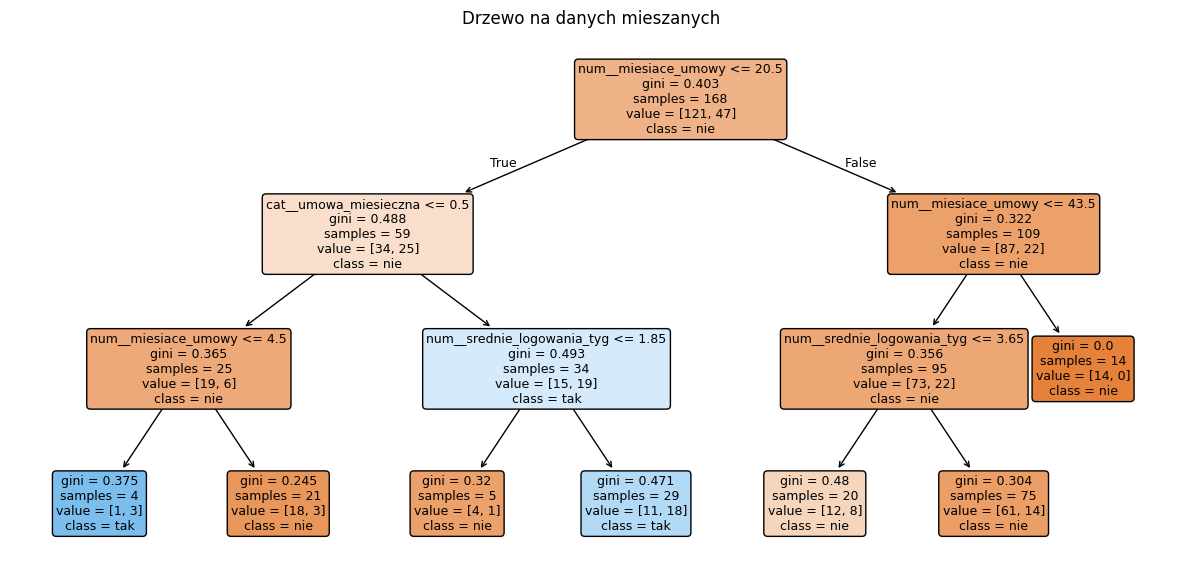

|--- num__miesiace_umowy <= 20.50
|   |--- cat__umowa_miesieczna <= 0.50
|   |   |--- num__miesiace_umowy <= 4.50
|   |   |   |--- class: tak
|   |   |--- num__miesiace_umowy >  4.50
|   |   |   |--- class: nie
|   |--- cat__umowa_miesieczna >  0.50
|   |   |--- num__srednie_logowania_tyg <= 1.85
|   |   |   |--- class: nie
|   |   |--- num__srednie_logowania_tyg >  1.85
|   |   |   |--- class: tak
|--- num__miesiace_umowy >  20.50
|   |--- num__miesiace_umowy <= 43.50
|   |   |--- num__srednie_logowania_tyg <= 3.65
|   |   |   |--- class: nie
|   |   |--- num__srednie_logowania_tyg >  3.65
|   |   |   |--- class: nie
|   |--- num__miesiace_umowy >  43.50
|   |   |--- class: nie



In [5]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()
tree = pipe.named_steps["tree"]

plt.figure(figsize=(15, 7))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=list(tree.classes_),
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=9
)
plt.title("Drzewo na danych mieszanych")
plt.show()

print(export_text(tree, feature_names=list(feature_names)))

## 4. Ważność cech

Ważność cechy w drzewie to nie „prawda o świecie”. To informacja, jak bardzo dana cecha pomagała temu konkretnemu drzewu redukować nieczystość.

In [6]:
importance = pd.DataFrame({
    "cecha_po_transformacji": feature_names,
    "importance": tree.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(10)

,cecha_po_transformacji,importance
0,num__miesiace_umowy,0.562537
2,num__srednie_logowania_tyg,0.219397
7,cat__umowa_miesieczna,0.218066
1,num__liczba_reklamacji,0.000000
3,cat__plan_basic,0.000000
5,cat__plan_pro,0.000000
4,cat__plan_premium,0.000000
6,cat__umowa_dwuletnia,0.000000
8,cat__umowa_roczna,0.000000
9,cat__rabat_nie,0.000000


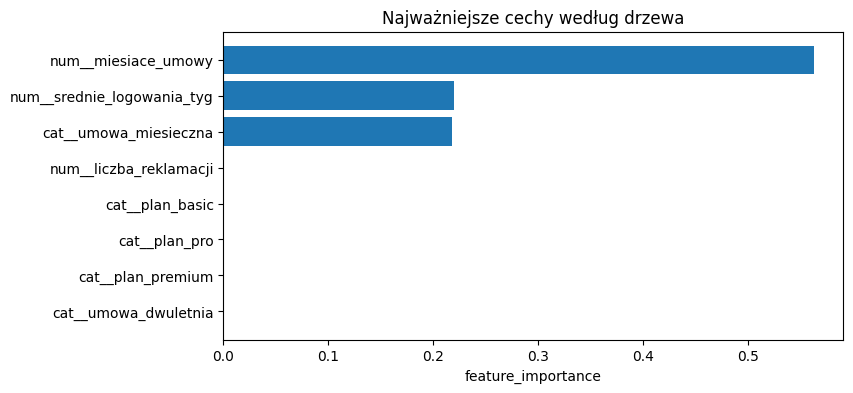

In [7]:
plt.figure(figsize=(8, 4))
top = importance.head(8).iloc[::-1]
plt.barh(top["cecha_po_transformacji"], top["importance"])
plt.xlabel("feature_importance")
plt.title("Najważniejsze cechy według drzewa")
plt.show()

## 5. Ścieżka decyzyjna dla jednego klienta

Dla pojedynczego przykładu możemy sprawdzić, przez które węzły przeszedł model.

### Dlaczego ścieżka decyzyjna jest ciekawa?

Ścieżka decyzyjna pokazuje, przez które pytania przeszedł konkretny klient.

To jest przydatne, gdy chcemy odpowiedzieć:

```text
Dlaczego model uznał, że ten klient odejdzie?
```

Przy pojedynczym drzewie jest to stosunkowo łatwe.  
Przy Random Forest będzie trudniejsze, bo tam decyzja pochodzi z wielu drzew naraz.

In [8]:
sample = X_test.iloc[[0]]
print("Oryginalny klient:")
print(sample.to_string(index=False))
print("Prawdziwa etykieta:", y_test.iloc[0])
print("Predykcja:", pipe.predict(sample)[0])

Xt = pipe.named_steps["prep"].transform(sample)
node_indicator = tree.decision_path(Xt)
leaf_id = tree.apply(Xt)

node_index = node_indicator.indices[node_indicator.indptr[0]: node_indicator.indptr[1]]
Xt_dense = np.asarray(Xt)

print("\nŚcieżka:")
for node_id in node_index:
    if leaf_id[0] == node_id:
        print(f"liść {node_id}: predykcja = {pipe.predict(sample)[0]}")
    else:
        feature_id = tree.tree_.feature[node_id]
        threshold = tree.tree_.threshold[node_id]
        fname = feature_names[feature_id]
        value = Xt_dense[0, feature_id]
        direction = "lewo" if value <= threshold else "prawo"
        print(f"węzeł {node_id}: {fname} = {value:.2f} <= {threshold:.2f}? -> {direction}")

Oryginalny klient:
 miesiace_umowy  liczba_reklamacji  srednie_logowania_tyg  plan  umowa rabat
             10                  0                    2.0 basic roczna   nie
Prawdziwa etykieta: nie
Predykcja: nie

Ścieżka:
węzeł 0: num__miesiace_umowy = 10.00 <= 20.50? -> lewo
węzeł 1: cat__umowa_miesieczna = 0.00 <= 0.50? -> lewo
węzeł 2: num__miesiace_umowy = 10.00 <= 4.50? -> prawo
liść 4: predykcja = nie


Ten notebook pokazuje pełny pipeline dla **pojedynczego drzewa**. Naturalne następne pytanie brzmi: co zrobić, jeśli jedno drzewo jest niestabilne albo zbyt mocno zależy od konkretnego podziału danych? Odpowiedzią w kolejnym notebooku będzie **Random Forest**, czyli wiele drzew głosujących razem.

## Ogólny wniosek z analizy

Model próbuje przewidzieć, czy klient odejdzie z usługi.

Z drzewa możemy odczytać, które cechy były ważne dla decyzji modelu.
W tym przykładzie szczególnie interesujące są cechy związane z:

- typem umowy,
- liczbą reklamacji,
- aktywnością klienta,
- długością relacji z firmą.

Interpretacja biznesowa jest taka:

```text
klienci z krótszą relacją, większą liczbą reklamacji
lub mniej stabilną formą umowy mogą mieć większe ryzyko odejścia

## Mini-podsumowanie

Ten notebook przenosi nas z przykładów dydaktycznych do bardziej realistycznego pipeline'u.

Najważniejsze idee:

```text
1. Dane tekstowe trzeba zakodować.
2. Braki danych trzeba obsłużyć.
3. Pipeline łączy preprocessing i model.
4. Accuracy warto porównywać z baseline'em.
5. Pojedyncze drzewo nadal można interpretować przez reguły i ścieżki.
```

To jest bezpośrednie przygotowanie do Random Forest.

## Ćwiczenia dla studentów


### Ćwiczenie 1: głębokość drzewa

Zmień `max_depth` na `2`, `3`, `5`.

Sprawdź:

- accuracy test,
- liczbę liści,
- czy drzewo nadal da się łatwo czytać.

In [15]:
for depth in [2, 3, 5]:
    pipe_tmp = Pipeline([
        ("prep", preprocess),
        ("tree", DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=4,
            random_state=42
        ))
    ])

    pipe_tmp.fit(X_train, y_train)
    tree_tmp = pipe_tmp.named_steps["tree"]

    print("max_depth:", depth)
    print("liczba liści:", tree_tmp.get_n_leaves())
    print("accuracy test:", round(accuracy_score(y_test, pipe_tmp.predict(X_test)), 3))
    print("-" * 40)

max_depth: 2
liczba liści: 4
accuracy test: 0.681
----------------------------------------
max_depth: 3
liczba liści: 7
accuracy test: 0.653
----------------------------------------
max_depth: 5
liczba liści: 17
accuracy test: 0.569
----------------------------------------


### Ćwiczenie 2: model bez reklamacji

Sprawdź, co się stanie, gdy usuniemy cechę `liczba_reklamacji`.

Czy model nadal działa podobnie?

In [16]:
X_no_complaints = X.drop(columns=["liczba_reklamacji"])

num_cols_no_complaints = ["miesiace_umowy", "srednie_logowania_tyg"]
cat_cols_no_complaints = ["plan", "umowa", "rabat"]

preprocess_no_complaints = ColumnTransformer([
    ("num", num_pipe, num_cols_no_complaints),
    ("cat", cat_pipe, cat_cols_no_complaints)
])

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_complaints,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

pipe_no_complaints = Pipeline([
    ("prep", preprocess_no_complaints),
    ("tree", DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=4,
        random_state=42
    ))
])

pipe_no_complaints.fit(X_train_nc, y_train_nc)

print("Model pełny accuracy test:",
      round(accuracy_score(y_test, pipe.predict(X_test)), 3))

print("Model bez reklamacji accuracy test:",
      round(accuracy_score(y_test_nc, pipe_no_complaints.predict(X_test_nc)), 3))

Model pełny accuracy test: 0.653
Model bez reklamacji accuracy test: 0.653


W tym konkretnym podziale danych usunięcie `liczba_reklamacji` nie zmieniło accuracy test.
To nie znaczy, że cecha jest zawsze nieistotna.
Oznacza tylko, że w tym prostym drzewie i tym podziale danych model potrafił osiągnąć podobny wynik bez niej.

### Ćwiczenie 3: minimalny rozmiar liścia

Zmień `min_samples_leaf` na `1`, `4`, `8`.

Sprawdź, czy większy liść upraszcza drzewo.

In [17]:
for leaf_size in [1, 4, 8]:
    pipe_tmp = Pipeline([
        ("prep", preprocess),
        ("tree", DecisionTreeClassifier(
            max_depth=3,
            min_samples_leaf=leaf_size,
            random_state=42
        ))
    ])

    pipe_tmp.fit(X_train, y_train)
    tree_tmp = pipe_tmp.named_steps["tree"]

    print("min_samples_leaf:", leaf_size)
    print("liczba liści:", tree_tmp.get_n_leaves())
    print("accuracy test:", round(accuracy_score(y_test, pipe_tmp.predict(X_test)), 3))
    print("-" * 40)

min_samples_leaf: 1
liczba liści: 7
accuracy test: 0.653
----------------------------------------
min_samples_leaf: 4
liczba liści: 7
accuracy test: 0.653
----------------------------------------
min_samples_leaf: 8
liczba liści: 7
accuracy test: 0.722
----------------------------------------


Większy `min_samples_leaf` ogranicza bardzo małe liście.
W tym przykładzie poprawia wynik testowy, bo model mniej dopasowuje się do drobnych przypadków treningowych.

## Wniosek z analizy

W tym przykładzie pojedyncze drzewo nie pokonało prostego baseline'u.
To jest ważna lekcja praktyczna: sam fakt użycia modelu ML nie gwarantuje lepszej predykcji.

Drzewo jest jednak bardzo wartościowe interpretacyjnie.
Pokazuje, jak model próbuje podejmować decyzje:

- krótszy staż klienta (`miesiace_umowy`) pojawia się jako główny podział,
- umowa miesięczna jest ważnym sygnałem wśród krótszych relacji,
- niska aktywność (`srednie_logowania_tyg`) pomaga rozdzielać część klientów.

Biznesowo można to czytać jako hipotezę:

klienci z krótszą relacją, umową miesięczną i niższą aktywnością mogą wymagać większej uwagi retencyjnej.

Ale ponieważ jakość predykcyjna pojedynczego drzewa jest słabsza niż baseline,
nie traktujemy tego jeszcze jako gotowego modelu produkcyjnego.
To raczej pierwszy, interpretowalny model i punkt wyjścia do Random Forest oraz XGBoost.

# Pojedyncze drzewo próbuje rozróżniać klientów, ale nadal słabo wykrywa klasę `tak`.

# To jest naturalna motywacja do kolejnego kroku: zamiast jednego drzewa użyjmy wielu drzew.